<a href="https://colab.research.google.com/github/bhakya01/OIBSIP/blob/main/superstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   EDA on Retail Sales Data SuperStore_Orders

 Load dataset and perform

In [ ]:

from google.colab import files
import pandas as pd
uploaded = files.upload()
df = pd.read_csv("SuperStore_Orders.csv",encoding="latin-1")

df

Saving SuperStore_Orders.csv to SuperStore_Orders.csv


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31-12-2014,04-01-2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,05-01-2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,02-01-2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,06-01-2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [ ]:
df.shape
df.columns
df.dtypes


,0
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_name,object
segment,object
state,object
country,object
market,object
region,object


Descriptive statistic

In [ ]:

# Display data
print(df)

# Missing values by column
print(df.isnull().sum())

# Total missing values
print("Total missing values:", df.isnull().sum().sum())


              order_id  order_date   ship_date       ship_mode  \
0         AG-2011-2040  01-01-2011  06-01-2011  Standard Class   
1        IN-2011-47883  01-01-2011  08-01-2011  Standard Class   
2         HU-2011-1220  01-01-2011  05-01-2011    Second Class   
3      IT-2011-3647632  01-01-2011  05-01-2011    Second Class   
4        IN-2011-47883  01-01-2011  08-01-2011  Standard Class   
...                ...         ...         ...             ...   
51285   CA-2014-115427  31-12-2014  04-01-2015  Standard Class   
51286     MO-2014-2560  31-12-2014  05-01-2015  Standard Class   
51287   MX-2014-110527  31-12-2014  02-01-2015    Second Class   
51288   MX-2014-114783  31-12-2014  06-01-2015  Standard Class   
51289   CA-2014-156720  31-12-2014  04-01-2015  Standard Class   

          customer_name      segment             state        country  market  \
0       Toby Braunhardt     Consumer       Constantine        Algeria  Africa   
1           Joseph Holt     Consumer   New So

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

# Calculate descriptive statistics
descriptive_stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Standard Deviation': df[numeric_cols].std()
})

# Display the result
descriptive_stats

,Mean,Median,Mode,Standard Deviation
quantity,3.476545,3.00,2.00,2.278766
discount,0.142908,0.00,0.00,0.212280
profit,28.641740,9.24,0.00,174.424113
shipping_cost,26.375915,7.79,0.86,57.296804
year,2012.777208,2013.00,2014.00,1.098931


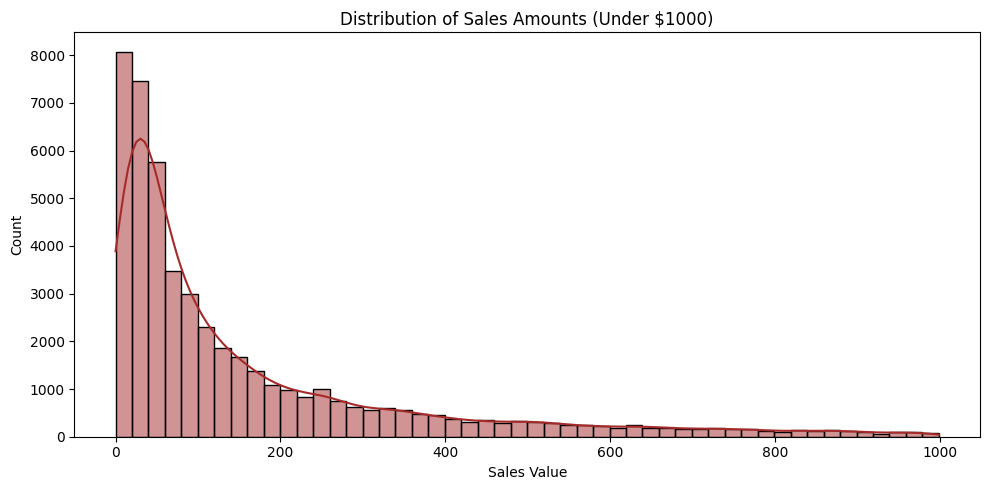

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The dataset 'df' is already loaded and cleaned in memory.
# Let's plot a clean distribution of the sales transaction values.
plt.figure(figsize=(10, 5))
sns.histplot(df[df['sales'] < 1000]['sales'], bins=50, kde=True, color='brown')
plt.title('Distribution of Sales Amounts (Under $1000)')
plt.xlabel('Sales Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

 Time series analysis:

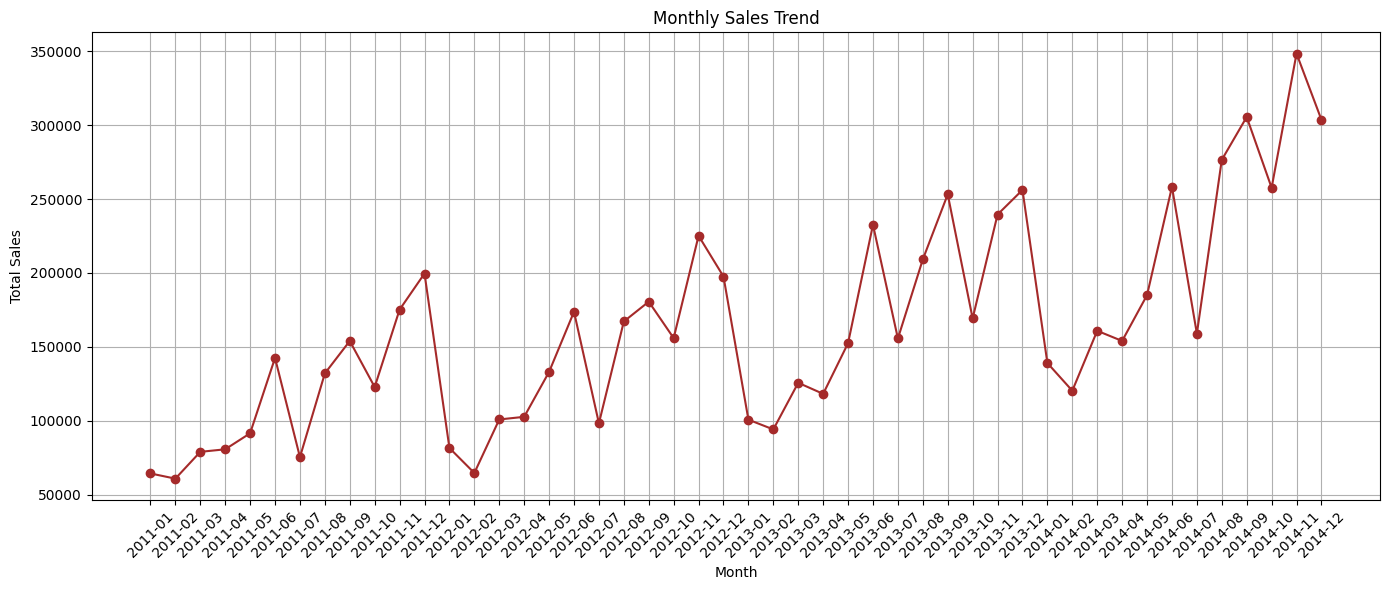

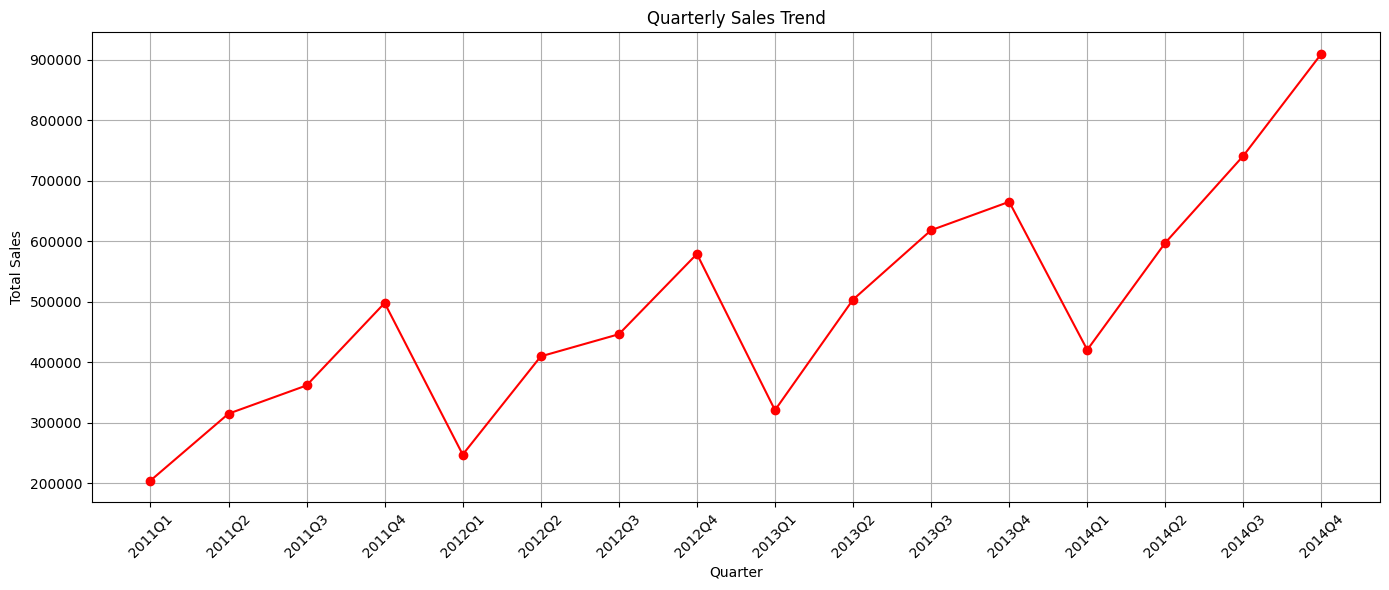

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the dataset is loaded (using the uploaded file)
try:
    if 'df' not in locals():
        df = pd.read_csv("SuperStore_Orders.csv", encoding="latin-1")
except Exception:
    # Fallback to the duplicate upload file if necessary
    df = pd.read_csv("SuperStore_Orders (2).csv", encoding="latin-1")

# Ensure 'order_date' is datetime and 'sales' is numeric
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y', errors='coerce')
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

# Drop rows where 'order_date' or 'sales' became NaN due to conversion errors
df.dropna(subset=['order_date', 'sales'], inplace=True)

# Monthly Sales Trend
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()
monthly_sales.index = monthly_sales.index.astype(str) # Convert PeriodIndex to string for plotting

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='brown')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Quarterly Sales Trend
quarterly_sales = df.groupby(df['order_date'].dt.to_period('Q'))['sales'].sum()
quarterly_sales.index = quarterly_sales.index.astype(str) # Convert PeriodIndex to string for plotting

plt.figure(figsize=(14, 6))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker='o', linestyle='-', color='red')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Observations on Monthly and Quarterly Sales Trends:

*   **Monthly Sales Trend:**
*   **Quarterly Sales Trend:**


Customer demographics analysis:

Note: The DataFrame does not contain 'age' or 'gender' columns for direct age group and gender breakdown analysis.
Therefore, a direct analysis of age and gender demographics cannot be performed with this dataset.
However, we can analyze the 'segment' column as an alternative form of customer segmentation.

Customer Segment Distribution:
segment
Consumer       25185
Corporate      14629
Home Office     8846
Name: count, dtype: int64


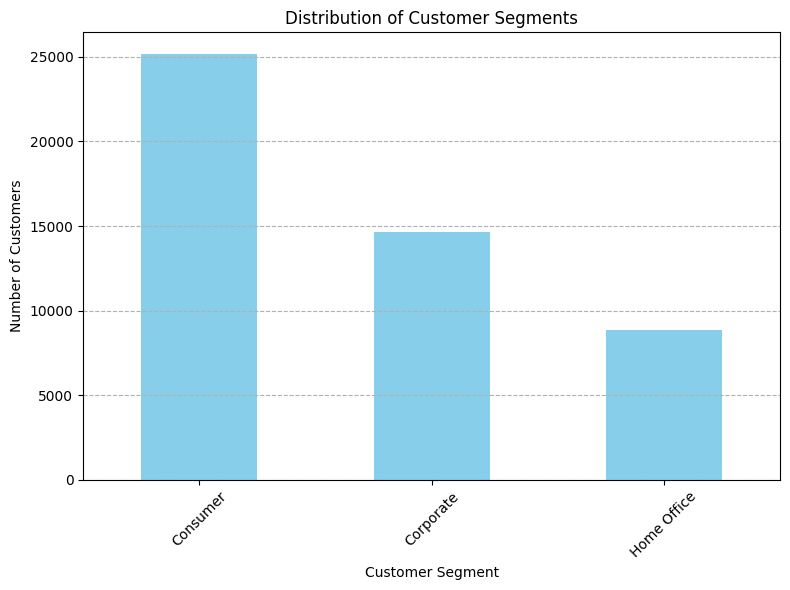

In [ ]:
import matplotlib.pyplot as plt

print("Note: The DataFrame does not contain 'age' or 'gender' columns for direct age group and gender breakdown analysis.")
print("Therefore, a direct analysis of age and gender demographics cannot be performed with this dataset.")
print("However, we can analyze the 'segment' column as an alternative form of customer segmentation.")

# Analyze customer segment distribution
segment_distribution = df['segment'].value_counts()
print("\nCustomer Segment Distribution:")
print(segment_distribution)

# Plotting segment distribution
plt.figure(figsize=(8, 6))
segment_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### Observations on Customer Segment Distribution:

*   **Segment Breakdown:**


In [ ]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [ ]:
top_10_products = (
    df.groupby('product_name')['quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_10_products)

product_name
Staples                                  876
Cardinal Index Tab, Clear                337
Eldon File Cart, Single Width            293
Sanford Pencil Sharpener, Water Color    259
Stockwell Paper Clips, Assorted Sizes    253
Avery Index Tab, Clear                   252
Ibico Index Tab, Clear                   251
Stanley Pencil Sharpener, Water Color    242
Acco Index Tab, Clear                    228
Boston Pencil Sharpener, Water Color     217
Name: quantity, dtype: int64


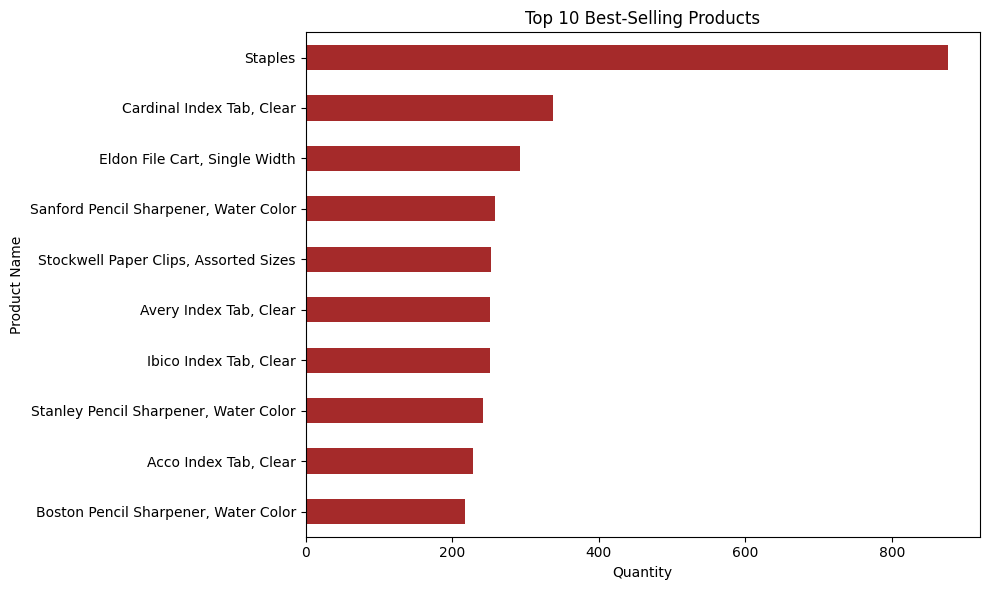

In [ ]:
import matplotlib.pyplot as plt

# Ensure top_10_products is calculated
top_10_products = (
    df.groupby('product_name')['quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
top_10_products.sort_values().plot(kind='barh', color='brown')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Quantity')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

### Observations on Top 10 Best-Selling Products:

*   **Key Products:**


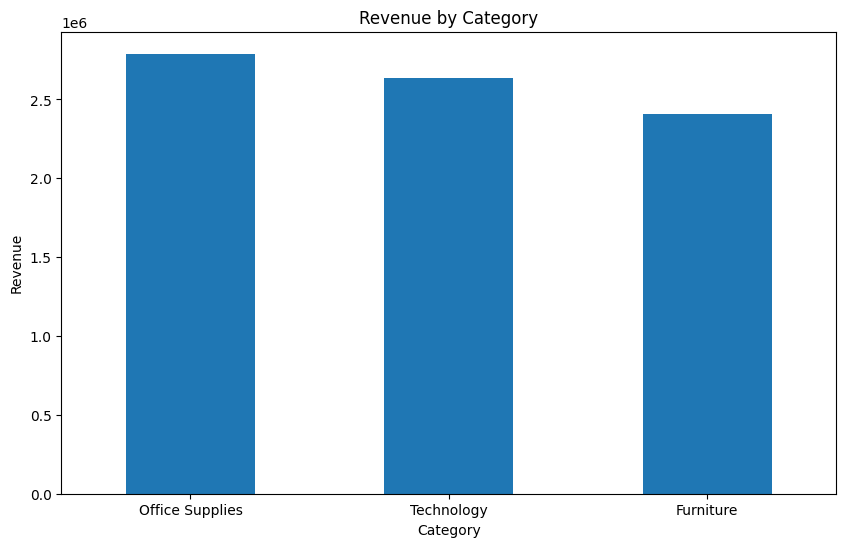

In [ ]:
# Ensure 'sales' column is numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

# Calculate total revenue by category
category_revenue = df.groupby('category')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
category_revenue.plot(kind = 'bar')
plt.title('Revenue by Category')
plt.xlabel('Category') # Corrected from pltxlabels
plt.ylabel('Revenue')  # Corrected from plt.ylabels
plt.xticks(rotation=0)
plt.show()

### Observations on Revenue by Category:

*   **Category Performance:**


In [ ]:
# Select numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Display correlation matrix
print(correlation_matrix)

                  sales  quantity  discount    profit  shipping_cost      year
sales          1.000000  0.276072 -0.106719  0.252703       0.771133 -0.002479
quantity       0.276072  1.000000 -0.008913  0.043134       0.207242 -0.006984
discount      -0.106719 -0.008913  1.000000 -0.472681      -0.081453 -0.005690
profit         0.252703  0.043134 -0.472681  1.000000       0.204664  0.005668
shipping_cost  0.771133  0.207242 -0.081453  0.204664       1.000000 -0.002724
year          -0.002479 -0.006984 -0.005690  0.005668      -0.002724  1.000000


 Heatmap

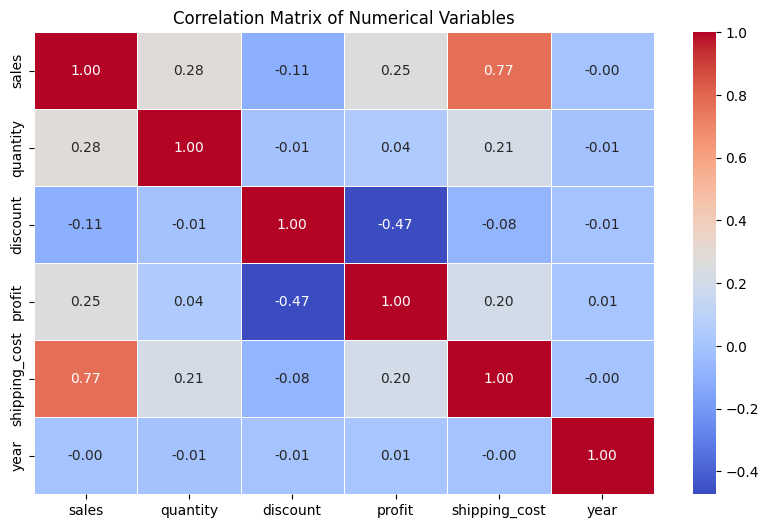

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Observations on Correlation Matrix of Numerical Variables:

*   **Correlations:**


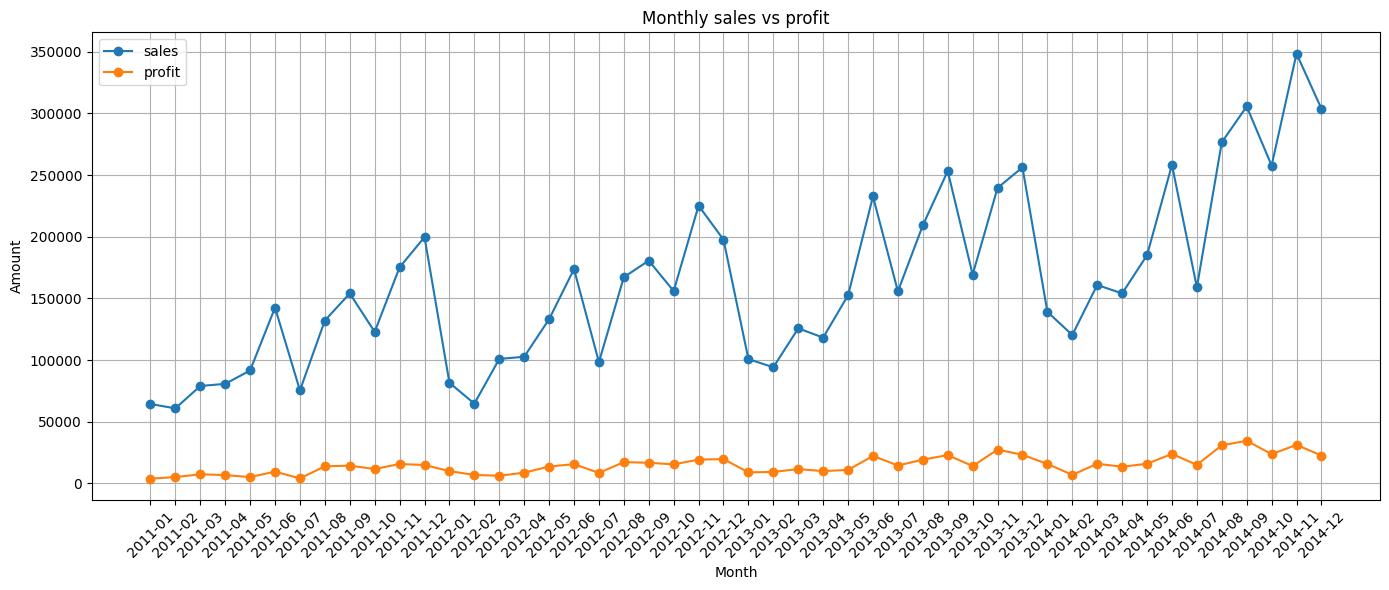

In [ ]:
# Convert Order Date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Create Month column
df['Month'] = df['order_date'].dt.to_period('M').astype(str)

# Group Sales and Profit by month
monthly_data = df.groupby('Month')[['sales', 'profit']].sum().reset_index()

# Plot
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_data['Month'],
    monthly_data['sales'],
    marker='o',
    label='sales'
)

plt.plot(
    monthly_data['Month'],
    monthly_data['profit'],
    marker='o',
    label='profit'
)

plt.title('Monthly sales vs profit')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observations on Monthly Sales vs. Profit:

*   **Sales and Profit Relationship:**


In [ ]:
Observations on Monthly Sales vs. Profit:
Sales and Profit Relationship:

In [ ]:
### Conclusion and Business Recommendations:

Based on the analysis of the SuperStore sales data, here are some actionable business recommendations:

1.  **Optimize Discounting Strategy for Profitability:** The strong negative correlation between 'discount' and 'profit' suggests that current discounting practices might be eroding profit margins. It is recommended to review the discount policies, possibly by setting minimum profit thresholds for discounted items, targeting discounts more strategically to clear slow-moving inventory, or offering value-added services instead of direct price reductions to maintain perceived product value. This could lead to a significant increase in overall profitability.

2.  **Enhance Inventory Management for Top-Selling Products:** Products like 'Staples' and other office supplies consistently appear among the best-selling items by quantity. To capitalize on this demand and ensure customer satisfaction, it is crucial to implement robust inventory management systems for these popular items. This includes forecasting demand accurately, optimizing stock levels to prevent stockouts, and exploring bulk purchasing opportunities to improve cost efficiency.

3.  **Strategic Focus on High-Revenue Categories:** 'Office Supplies' and 'Technology' are the top revenue-generating categories. The business should consider allocating more marketing resources, product development efforts, and sales incentives towards these categories to further leverage their high performance. Additionally, a deeper dive into the 'Furniture' category, which has lower revenue, could identify areas for improvement or strategic divestment if it proves to be a low-profitability segment.